# Étude approfondie — quand le DANN aide-t-il la portabilité ? (Colab GPU)

**Hypothèse centrale :** *le bénéfice de l'adaptation de domaine croît avec l'ampleur
du décalage entre l'appareil source et l'appareil cible.*

Trois briques pour la tester, toutes sur `AES_PT_light.h5` :
1. **Distance entre appareils** — un classifieur D1 vs Dx mesure le décalage ; on
   corrèle ce décalage au gain du DANN.
2. **Boîte noire** — précision-domaine au fil des époques + projection PCA des
   représentations, pour *expliquer* l'asymétrie.
3. **Robustesse multi-octets** — moyenne sur plusieurs octets de clé pour réduire
   le bruit.

> Active le **GPU T4**. Mets `AES_PT_light.h5` dans `MyDrive/dl-sca/`.
> Certaines cellules ré-entraînent plusieurs modèles : compte quelques minutes par cible.

## 0. Setup, boîte à outils, modèles

In [1]:
import os, numpy as np, tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/crypto'
AES_PT_PATH = os.path.join(DATA_DIR, 'AES_PT_light.h5')
FIG_DIR = os.path.join(DATA_DIR, 'figures'); os.makedirs(FIG_DIR, exist_ok=True)
gpus = tf.config.list_physical_devices('GPU')
print('GPU :', bool(gpus), '| Fichier :', 'présent' if os.path.exists(AES_PT_PATH) else 'ABSENT')

Mounted at /content/drive
GPU : True | Fichier : présent


In [2]:
import h5py
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models, optimizers

AES_SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16,
], dtype=np.uint8)

def load_aes_pt(path, device='D1', impl='Unprotected', keytype='RndmKey', byte=0, n=None):
    base=f'{device}/{impl}/{keytype}'
    with h5py.File(path,'r') as f:
        tr=f[f'{base}/Traces']; N=tr.shape[0] if n is None else min(int(n),tr.shape[0])
        traces=np.asarray(tr[:N],dtype=np.float32)
        pt=np.asarray(f[f'{base}/Data/Plaintext'][:N,byte],dtype=np.uint8)
        key=np.asarray(f[f'{base}/Data/Key'][:N,byte],dtype=np.uint8)
    return {'traces':traces,'labels':AES_SBOX[pt^key].astype(np.int64),'pt':pt,'key':key}

def guessing_entropy(preds, pt, true_key, n_attack=5000, n_exp=50, seed=0):
    rng=np.random.default_rng(seed); lp=np.log(preds+1e-40); N=preds.shape[0]
    n_attack=min(n_attack,N); kh=np.arange(256,dtype=np.uint8); ge=np.zeros(n_attack)
    for _ in range(n_exp):
        idx=rng.permutation(N)[:n_attack]; s=np.zeros(256)
        for st,i in enumerate(idx):
            s+=lp[i,AES_SBOX[pt[i]^kh]]; ge[st]+=np.count_nonzero(s>s[true_key])
    return ge/n_exp

def traces_to_break(ge, thresh=0.5):
    hit=np.where(ge<thresh)[0]; return int(hit[0]+1) if len(hit) else None

In [3]:
def make_mlp(n, lr=1e-3):
    m=models.Sequential([layers.Input((n,))]+[layers.Dense(200,activation='relu') for _ in range(4)]+
        [layers.Dense(256,activation='softmax')])
    m.compile(optimizer=optimizers.Adam(lr),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return m

class GradReverse(layers.Layer):
    def __init__(self,**kw):
        super().__init__(**kw); self.lamb=self.add_weight(name='lamb',shape=(),initializer='zeros',trainable=False)
    def call(self,x):
        lam=self.lamb
        @tf.custom_gradient
        def f(z): return tf.identity(z), lambda dy: -lam*dy
        return f(x)

def build_dann(n):
    inp=layers.Input((n,))
    x=layers.Dense(200,activation='relu')(inp); x=layers.Dense(200,activation='relu')(x)
    feat=layers.Dense(200,activation='relu',name='feat')(x)     # couche extraite pour la PCA
    c=layers.Dense(200,activation='relu')(feat)
    class_out=layers.Dense(256,activation='softmax',name='class')(c)
    grl=GradReverse(name='grl'); d=grl(feat); d=layers.Dense(100,activation='relu')(d)
    domain_out=layers.Dense(2,activation='softmax',name='domain')(d)
    m=models.Model(inp,{'class':class_out,'domain':domain_out})
    m.compile(optimizer=optimizers.Adam(1e-3),
        loss={'class':'sparse_categorical_crossentropy','domain':'sparse_categorical_crossentropy'},
        metrics={'class':'accuracy','domain':'accuracy'})
    return m,grl

class LambdaSchedule(tf.keras.callbacks.Callback):
    def __init__(self,grl,total,warmup=30,gamma=10.0,max_lambda=0.1):
        self.grl=grl;self.total=total;self.warmup=warmup;self.gamma=gamma;self.maxl=max_lambda
    def on_epoch_begin(self,epoch,logs=None):
        if epoch<self.warmup: lam=0.0
        else:
            p=(epoch-self.warmup)/max(1,self.total-self.warmup-1)
            lam=(2.0/(1.0+np.exp(-self.gamma*p))-1.0)*self.maxl
        self.grl.lamb.assign(np.float32(lam))

## 1. Réglages communs et fonction d'expérience

In [4]:
SRC_DEV   = 'D1'
TARGETS   = ['D2','D3','D4']
N_TRAIN, EPOCHS, WARMUP, MAX_LAMBDA, N_EXP = 40000, 60, 30, 0.1, 50
N_ATTACK = 5000

def prepare(target, byte, n_train=N_TRAIN):
    src=load_aes_pt(AES_PT_PATH, SRC_DEV,'Unprotected','RndmKey',byte=byte,n=n_train)
    tgt=load_aes_pt(AES_PT_PATH, target,'Unprotected','RndmKey',byte=byte,n=n_train)
    ss=StandardScaler().fit(src['traces']); st=StandardScaler().fit(tgt['traces'])
    Xs=ss.transform(src['traces']).astype(np.float32); Xt=st.transform(tgt['traces']).astype(np.float32)
    ns,nt=len(Xs),len(Xt)
    atk=load_aes_pt(AES_PT_PATH, target,'Unprotected','FixedKey',byte=byte,n=20000)
    return dict(Xs=Xs,Xt=Xt,src_labels=src['labels'],n=Xs.shape[1],ns=ns,nt=nt,
        X=np.concatenate([Xs,Xt]).astype(np.float32),
        y_class=np.concatenate([src['labels'],np.zeros(nt)]).astype(np.int64),
        y_domain=np.concatenate([np.zeros(ns),np.ones(nt)]).astype(np.int64),
        w_class=np.concatenate([np.ones(ns),np.zeros(nt)]).astype(np.float32),
        w_domain=np.ones(ns+nt,np.float32),
        Xa=st.transform(atk['traces']).astype(np.float32),
        pt=atk['pt'], tk=int(np.bincount(atk['key']).argmax()))

def train_dann(d, epochs=EPOCHS):
    m,g=build_dann(d['n']); s=LambdaSchedule(g,epochs,warmup=WARMUP,max_lambda=MAX_LAMBDA)
    h=m.fit(d['X'],{'class':d['y_class'],'domain':d['y_domain']},
        sample_weight={'class':d['w_class'],'domain':d['w_domain']},
        epochs=epochs,batch_size=128,shuffle=True,verbose=0,callbacks=[s])
    return m,h

def train_source_only(d, epochs=30):
    m=make_mlp(d['n']); m.fit(d['Xs'],d['src_labels'],epochs=epochs,batch_size=128,verbose=0); return m

def min_rank(model, d, head=None):
    p=model.predict(d['Xa'],batch_size=256,verbose=0); p=p[head] if head else p
    return guessing_entropy(p,d['pt'],d['tk'],n_attack=N_ATTACK,n_exp=N_EXP).min()

## 2. Brique 1 — distance entre appareils, et corrélation avec le gain DANN
Pour chaque cible : (a) on mesure le décalage D1$\to$Dx via un classifieur binaire
(proxy A-distance) ; (b) on entraîne source-seul et DANN ; (c) on corrèle.

In [5]:
def domain_distance(target, byte=0, n=8000, epochs=8):
    a=load_aes_pt(AES_PT_PATH, SRC_DEV,'Unprotected','RndmKey',byte=byte,n=n)['traces']
    b=load_aes_pt(AES_PT_PATH, target,'Unprotected','RndmKey',byte=byte,n=n)['traces']
    a=StandardScaler().fit_transform(a).astype(np.float32); b=StandardScaler().fit_transform(b).astype(np.float32)
    X=np.concatenate([a,b]); y=np.concatenate([np.zeros(len(a)),np.ones(len(b))]).astype(np.float32)
    idx=np.random.default_rng(0).permutation(len(X)); X,y=X[idx],y[idx]; cut=int(0.8*len(X))
    clf=models.Sequential([layers.Input((X.shape[1],)),layers.Dense(64,activation='relu'),layers.Dense(1,activation='sigmoid')])
    clf.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    clf.fit(X[:cut],y[:cut],epochs=epochs,batch_size=128,verbose=0)
    return float(clf.evaluate(X[cut:],y[cut:],verbose=0)[1])

rows=[]; HIST={}   # HIST garde les historiques DANN pour la Brique 2
for tgt in TARGETS:
    print('=== cible', tgt, '===')
    dist=domain_distance(tgt)
    d=prepare(tgt, byte=0)
    so=train_source_only(d);  r_so=min_rank(so,d)
    dn,h=train_dann(d);       r_dn=min_rank(dn,d,head='class'); HIST[tgt]=h.history
    rows.append({'cible':tgt,'distance':round(dist,3),'rang_source':round(r_so,1),
                 'rang_dann':round(r_dn,1),'gain':round(r_so-r_dn,1)})
    print(f'  distance={dist:.3f} | source={r_so:.1f} | DANN={r_dn:.1f} | gain={r_so-r_dn:+.1f}')

import pandas as pd
df=pd.DataFrame(rows).set_index('cible'); print('\n(gain>0 = le DANN aide)'); df

=== cible D2 ===
  distance=1.000 | source=17.7 | DANN=37.8 | gain=-20.1
=== cible D3 ===
  distance=1.000 | source=65.9 | DANN=42.5 | gain=+23.4
=== cible D4 ===
  distance=1.000 | source=74.9 | DANN=67.4 | gain=+7.5

(gain>0 = le DANN aide)


,distance,rang_source,rang_dann,gain
cible,,,,
D2,1.0,17.7,37.8,-20.1
D3,1.0,65.9,42.5,23.4
D4,1.0,74.9,67.4,7.5


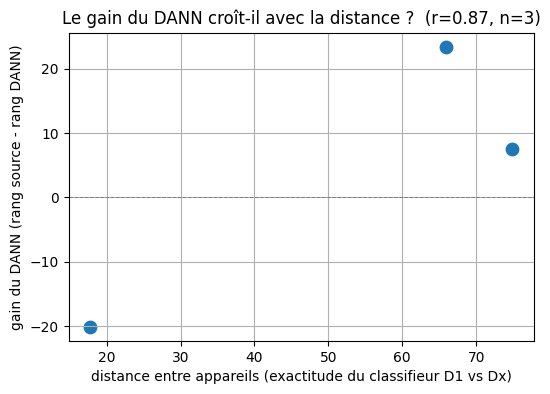

Corrélation de Pearson : 0.87 (n=3 : illustratif ; la Brique 3 ajoute des points)


In [6]:
import matplotlib.pyplot as plt
x=[r['rang_source'] for r in rows]; y=[r['gain'] for r in rows]
r_pearson=np.corrcoef(x,y)[0,1] if len(x)>1 else float('nan')
plt.figure(figsize=(6,4))
plt.scatter(x,y,s=80)
for r in rows: plt.annotate(r['cible'],(r['distance'],r['gain']),textcoords='offset points',xytext=(6,4))
plt.axhline(0,color='gray',lw=0.7,ls='--')
plt.xlabel('distance entre appareils (exactitude du classifieur D1 vs Dx)')
plt.ylabel('gain du DANN (rang source - rang DANN)')
plt.title(f'Le gain du DANN croît-il avec la distance ?  (r={r_pearson:.2f}, n={len(x)})')
plt.grid(True); plt.savefig(os.path.join(FIG_DIR,'C_distance_vs_gain.pdf'),bbox_inches='tight'); plt.show()
print('Corrélation de Pearson :', round(r_pearson,2), '(n=3 : illustratif ; la Brique 3 ajoute des points)')

## 3. Brique 2 — ouvrir la boîte noire (pourquoi D4 ?)
Précision-domaine au fil des époques, puis projection PCA des représentations.

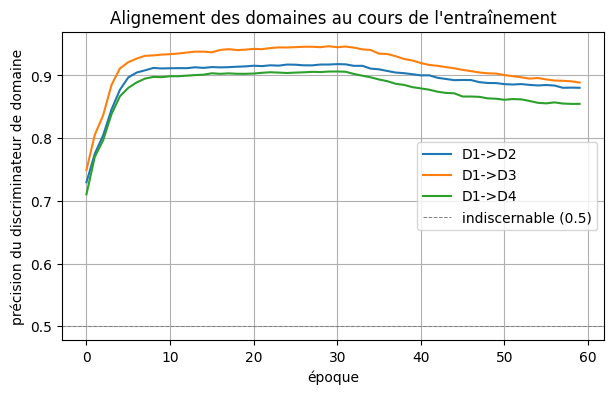

In [7]:
# (a) précision-domaine : doit chuter vers 0.5 si l'alignement opère
plt.figure(figsize=(7,4))
for tgt in TARGETS:
    if tgt in HIST: plt.plot(HIST[tgt]['domain_accuracy'], label=f'{SRC_DEV}->{tgt}')
plt.axhline(0.5,color='gray',ls='--',lw=0.7,label='indiscernable (0.5)')
plt.xlabel('époque'); plt.ylabel('précision du discriminateur de domaine')
plt.title("Alignement des domaines au cours de l'entraînement"); plt.legend(); plt.grid(True)
plt.savefig(os.path.join(FIG_DIR,'C_domain_accuracy.pdf'),bbox_inches='tight'); plt.show()

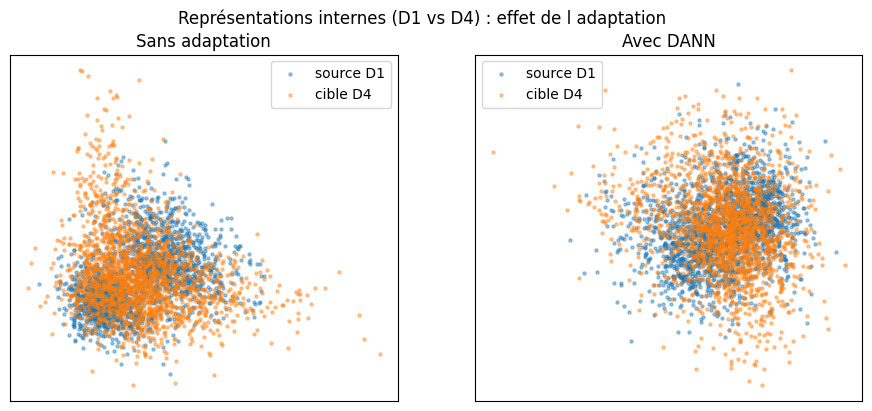

In [8]:
# (b) PCA des représentations source vs cible, sans adaptation puis avec DANN
from sklearn.decomposition import PCA
PCA_TARGET = 'D4'      # l'appareil où le DANN aide
d=prepare(PCA_TARGET, byte=0)
so=train_source_only(d); dn,_=train_dann(d)

feat_so = models.Sequential(so.layers[:-1])                    # tout sauf la couche softmax finale         # avant-dernière couche
feat_dn=models.Model(dn.input, dn.get_layer('feat').output)
m=2000   # échantillon pour la lisibilité
Fs_so,Ft_so=feat_so.predict(d['Xs'][:m],verbose=0),feat_so.predict(d['Xt'][:m],verbose=0)
Fs_dn,Ft_dn=feat_dn.predict(d['Xs'][:m],verbose=0),feat_dn.predict(d['Xt'][:m],verbose=0)

fig,ax=plt.subplots(1,2,figsize=(11,4.5))
for a,(Fs,Ft,titre) in zip(ax,[(Fs_so,Ft_so,'Sans adaptation'),(Fs_dn,Ft_dn,'Avec DANN')]):
    P=PCA(2).fit(np.concatenate([Fs,Ft])); Ps,Pt=P.transform(Fs),P.transform(Ft)
    a.scatter(Ps[:,0],Ps[:,1],s=5,alpha=.4,label='source D1'); a.scatter(Pt[:,0],Pt[:,1],s=5,alpha=.4,label=f'cible {PCA_TARGET}')
    a.set_title(titre); a.legend(); a.set_xticks([]); a.set_yticks([])
fig.suptitle(f'Représentations internes ({SRC_DEV} vs {PCA_TARGET}) : effet de l adaptation')
plt.savefig(os.path.join(FIG_DIR,'C_pca_features.pdf'),bbox_inches='tight'); plt.show()

## 4. Brique 3 — robustesse multi-octets
Moyenne du rang minimal sur plusieurs octets de clé, pour réduire le bruit
d'un octet unique. **Coûteux** : 2 entraînements par octet et par cible.
Commence avec peu d'octets, augmente si le temps le permet.

In [9]:
BYTES = [0,1,2,3,4,5,6,7]
BYTE_TARGETS = ['D2', 'D4']
res = {}
for tgt in BYTE_TARGETS:
    gains = []
    for b in BYTES:
        tf.keras.utils.set_random_seed(0)          # reproductibilité
        d = prepare(tgt, byte=b)
        r_so = min_rank(train_source_only(d), d)
        dn, _ = train_dann(d); r_dn = min_rank(dn, d, head='class')
        gains.append(r_so - r_dn)                   # gain par octet (>0 = DANN aide)
        print(f'  {tgt} octet {b}: source={r_so:.1f} dann={r_dn:.1f} gain={r_so-r_dn:+.1f}')
    g = np.array(gains); res[tgt] = (g.mean(), g.std())
    print(f'{tgt} : gain moyen {g.mean():+.1f} ± {g.std():.1f} sur {len(BYTES)} octets\n')

  D2 octet 0: source=50.8 dann=26.9 gain=+23.9
  D2 octet 1: source=35.1 dann=26.1 gain=+9.0
  D2 octet 2: source=8.7 dann=80.8 gain=-72.1
  D2 octet 3: source=0.5 dann=2.9 gain=-2.4
  D2 octet 4: source=129.4 dann=92.8 gain=+36.6
  D2 octet 5: source=1.2 dann=25.7 gain=-24.5
  D2 octet 6: source=0.1 dann=1.1 gain=-0.9
  D2 octet 7: source=0.1 dann=0.1 gain=+0.0
D2 : gain moyen -3.8 ± 31.0 sur 8 octets

  D4 octet 0: source=124.3 dann=88.2 gain=+36.1
  D4 octet 1: source=5.2 dann=12.6 gain=-7.4
  D4 octet 2: source=2.2 dann=21.4 gain=-19.2
  D4 octet 3: source=12.0 dann=8.2 gain=+3.7
  D4 octet 4: source=122.2 dann=72.4 gain=+49.8
  D4 octet 5: source=0.5 dann=20.1 gain=-19.7
  D4 octet 6: source=0.1 dann=0.1 gain=-0.1
  D4 octet 7: source=0.3 dann=0.4 gain=-0.1
D4 : gain moyen +5.4 ± 23.4 sur 8 octets



## Bilan
- **Brique 1** : le gain du DANN suit-il la distance entre appareils ? (figure `C_distance_vs_gain`)
- **Brique 2** : la précision-domaine chute-t-elle plus fort là où le DANN aide ? les
  nuages se superposent-ils après adaptation ? (`C_domain_accuracy`, `C_pca_features`)
- **Brique 3** : l'effet tient-il en moyenne sur plusieurs octets ?

Toutes les figures sont dans `FIG_DIR`, prêtes pour le rapport.